In [ ]:
import open3d as o3d
import numpy as np
import json
import os
from pathlib import Path
from glob import glob
from PIL import Image
import cv2
import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import defaultdict
import images_processing
import caption_generator

In [2]:
# scene_dir = 'ScanNet_Data/data/56a0ec536c'

# Change the scene: c9abde4c4b - toilet
# scene: 285efbc7cf - kitchen
scene_dir = 'ScanNet_Data/data/0a7cc12c0e'

# Change the scene: 0a7cc12c0e - bedroom
# scene_dir = 'ScanNet_Data/data/0a7cc12c0e'
mesh_file = scene_dir + '/scans/mesh_aligned_0.05_semantic.ply'
segments_file = scene_dir + '/scans/segments.json'
anno_file = scene_dir + '/scans/segments_anno.json'
output_dir = scene_dir + '/extracted_individual_objects'
os.makedirs(output_dir, exist_ok=True)
colmap_dir = os.path.join(scene_dir, 'dslr/colmap')
image_dir = os.path.join(scene_dir, 'dslr/resized_images')
region_crop_dir = scene_dir + '/region_crops'
os.makedirs(region_crop_dir, exist_ok=True)
region_dir = scene_dir + '/regions'
os.makedirs(region_dir, exist_ok=True)
region_top5_dir = os.path.join(scene_dir, 'region_cropped_top5')
os.makedirs(region_top5_dir, exist_ok=True)

In [3]:
mesh = o3d.io.read_triangle_mesh(mesh_file)
vertices = np.asarray(mesh.vertices)
triangles = np.asarray(mesh.triangles)
segment_ids = np.asarray(json.load(open(segments_file))['segIndices'])
anno_data = np.asarray(json.load(open(anno_file))['segGroups'])

In [4]:
segment_to_object = {}
object_to_label = {}
for object in anno_data:
    object_id = object['objectId']
    label = object['label']
    segments = object['segments']
    for segment_id in segments:
        segment_to_object[segment_id] = object_id
    object_to_label[object_id] = label

In [5]:
unique_instances = set(segment_to_object.values())
print(f'There are {len(unique_instances)} unique instances.')

There are 140 unique instances.


In [6]:
import os
import numpy as np
import cv2
import open3d as o3d
from PIL import Image
from collections import defaultdict

# read cameras.txt：support OPENCV_FISHEYE cameras
def read_cameras_text(path):
    cameras = {}
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#') or line.strip() == '':
                continue
            elems = line.strip().split()
            if elems[1] == "OPENCV_FISHEYE":
                camera_id = int(elems[0])
                width, height = int(elems[2]), int(elems[3])
                fx, fy, cx, cy = map(float, elems[4:8])
                distortion = list(map(float, elems[8:12]))
                cameras[camera_id] = {
                    'fx': fx, 'fy': fy, 'cx': cx, 'cy': cy,
                    'width': width, 'height': height,
                    'distortion': distortion
                }
    return cameras

# read images.txt：extract camera extrinsics
def read_images_text(path):
    images = {}
    with open(path, 'r') as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith("#") or line == "":
            i += 1
            continue
        elems = line.split()
        if len(elems) < 10:
            i += 1
            continue
        image_id = int(elems[0])
        qvec = np.array(list(map(float, elems[1:5])))
        tvec = np.array(list(map(float, elems[5:8])))
        camera_id = int(elems[8])
        image_name = elems[9]
        images[image_name] = {'qvec': qvec, 'tvec': tvec, 'camera_id': camera_id}
        i += 2
    return images

# qvec（qw, qx, qy, qz: Rotation Matrix R
def qvec2rotmat(qvec):
    w, x, y, z = qvec
    return np.array([
        [1 - 2*y**2 - 2*z**2,   2*x*y - 2*z*w,       2*x*z + 2*y*w],
        [2*x*y + 2*z*w,         1 - 2*x**2 - 2*z**2, 2*y*z - 2*x*w],
        [2*x*z - 2*y*w,         2*y*z + 2*x*w,       1 - 2*x**2 - 2*y**2]
    ])

# Map 3D mesh into 2D images according to camera intrinsics & extrinsics, crop the object and save it.
def crop_objects(colmap_dir, image_dir, object_dir, object_crop_dir, padding = None):
    os.makedirs(object_crop_dir, exist_ok=True)

    cameras = read_cameras_text(os.path.join(colmap_dir, 'cameras.txt'))
    images = read_images_text(os.path.join(colmap_dir, 'images.txt'))

    for obj_file in os.listdir(object_dir):
        if not obj_file.endswith('.ply'):
            continue
        obj_path = os.path.join(object_dir, obj_file)
        obj_mesh = o3d.io.read_triangle_mesh(obj_path)
        vertices = np.asarray(obj_mesh.vertices)
        print(f"Processing object: {obj_file}")

        for img_name, img_info in images.items():
            img_path = os.path.join(image_dir, img_name)
            if not os.path.exists(img_path):
                continue

            qvec, tvec, cam_id = img_info['qvec'], img_info['tvec'], img_info['camera_id']
            cam = cameras[cam_id]

            K = np.array([
                [cam['fx'], 0, cam['cx']],
                [0, cam['fy'], cam['cy']],
                [0, 0, 1]
            ])
            D = np.array(cam['distortion'])
            w, h = cam['width'], cam['height']

            R = qvec2rotmat(qvec)
            t = np.array(tvec).reshape((3, 1))
            verts_cam = (R @ vertices.T + t).T

            if np.any(verts_cam[:, 2] <= 0):
                continue

            verts_2d, _ = cv2.fisheye.projectPoints(
                verts_cam.reshape(-1, 1, 3),
                np.zeros((3, 1)), np.zeros((3, 1)),
                K, D
            )
            verts_2d = verts_2d.reshape(-1, 2)
            u, v = verts_2d[:, 0], verts_2d[:, 1]

            valid = (u >= 0) & (u < w) & (v >= 0) & (v < h)
            if np.sum(valid) < 5:
                continue

            # tight (no-padding) box
            raw_min_u, raw_max_u = np.percentile(u[valid], [5, 95]).astype(int)
            raw_min_v, raw_max_v = np.percentile(v[valid], [5, 95]).astype(int)

            # padding
            if padding is None:
                padding = 0
            padding_u = padding * (raw_max_u - raw_min_u)
            padding_v = padding * (raw_max_v - raw_min_v)

            min_u = max(0, raw_min_u - padding_u)
            max_u = min(w, raw_max_u + padding_u)
            min_v = max(0, raw_min_v - padding_v)
            max_v = min(h, raw_max_v + padding_v)

            if max_u <= min_u or max_v <= min_v:
                print(f"Skipping invalid crop for {img_name}")
                continue

            # crop the image
            image = np.array(Image.open(img_path))
            crop = image[min_v:max_v, min_u:max_u]

            box_min_u_in_crop = raw_min_u - min_u
            box_max_u_in_crop = raw_max_u - min_u
            box_min_v_in_crop = raw_min_v - min_v
            box_max_v_in_crop = raw_max_v - min_v

            # draw the tight box
            crop = cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)
            color = (0, 255, 0)  # Green box
            thickness = 2
            cv2.rectangle(
                crop,
                (int(box_min_u_in_crop), int(box_min_v_in_crop)),
                (int(box_max_u_in_crop), int(box_max_v_in_crop)),
                color,
                thickness
            )

            crop_name = f"{os.path.splitext(obj_file)[0]}_{os.path.splitext(img_name)[0]}.jpg"
            crop_path = os.path.join(object_crop_dir, crop_name)
            cv2.imwrite(crop_path, crop)
            print(f"Saved crop with bbox: {crop_name}")

In [7]:
colmap_dir = os.path.join(scene_dir, 'dslr/colmap')
image_dir = os.path.join(scene_dir, 'dslr/resized_images')
object_dir = scene_dir + '/extracted_individual_objects'
output_crop_dir = scene_dir + '/object_crops'
os.makedirs(output_crop_dir, exist_ok=True)
# crop_objects(colmap_dir=colmap_dir, image_dir=image_dir, object_dir=object_dir, object_crop_dir = output_crop_dir)

In [8]:
colmap_dir = os.path.join(scene_dir, 'dslr/colmap')
image_dir = os.path.join(scene_dir, 'dslr/resized_images')
object_dir = scene_dir + '/extracted_individual_objects'
output_crop_dir = scene_dir + '/object_crops_padding_bbox'
os.makedirs(output_crop_dir, exist_ok=True)
'''
crop_objects(colmap_dir=colmap_dir, 
             image_dir=image_dir, 
             object_dir=object_dir, 
             object_crop_dir = output_crop_dir,
             padding=1)
'''

'\ncrop_objects(colmap_dir=colmap_dir, \n             image_dir=image_dir, \n             object_dir=object_dir, \n             object_crop_dir = output_crop_dir,\n             padding=1)\n'

# Mapping Evaluation

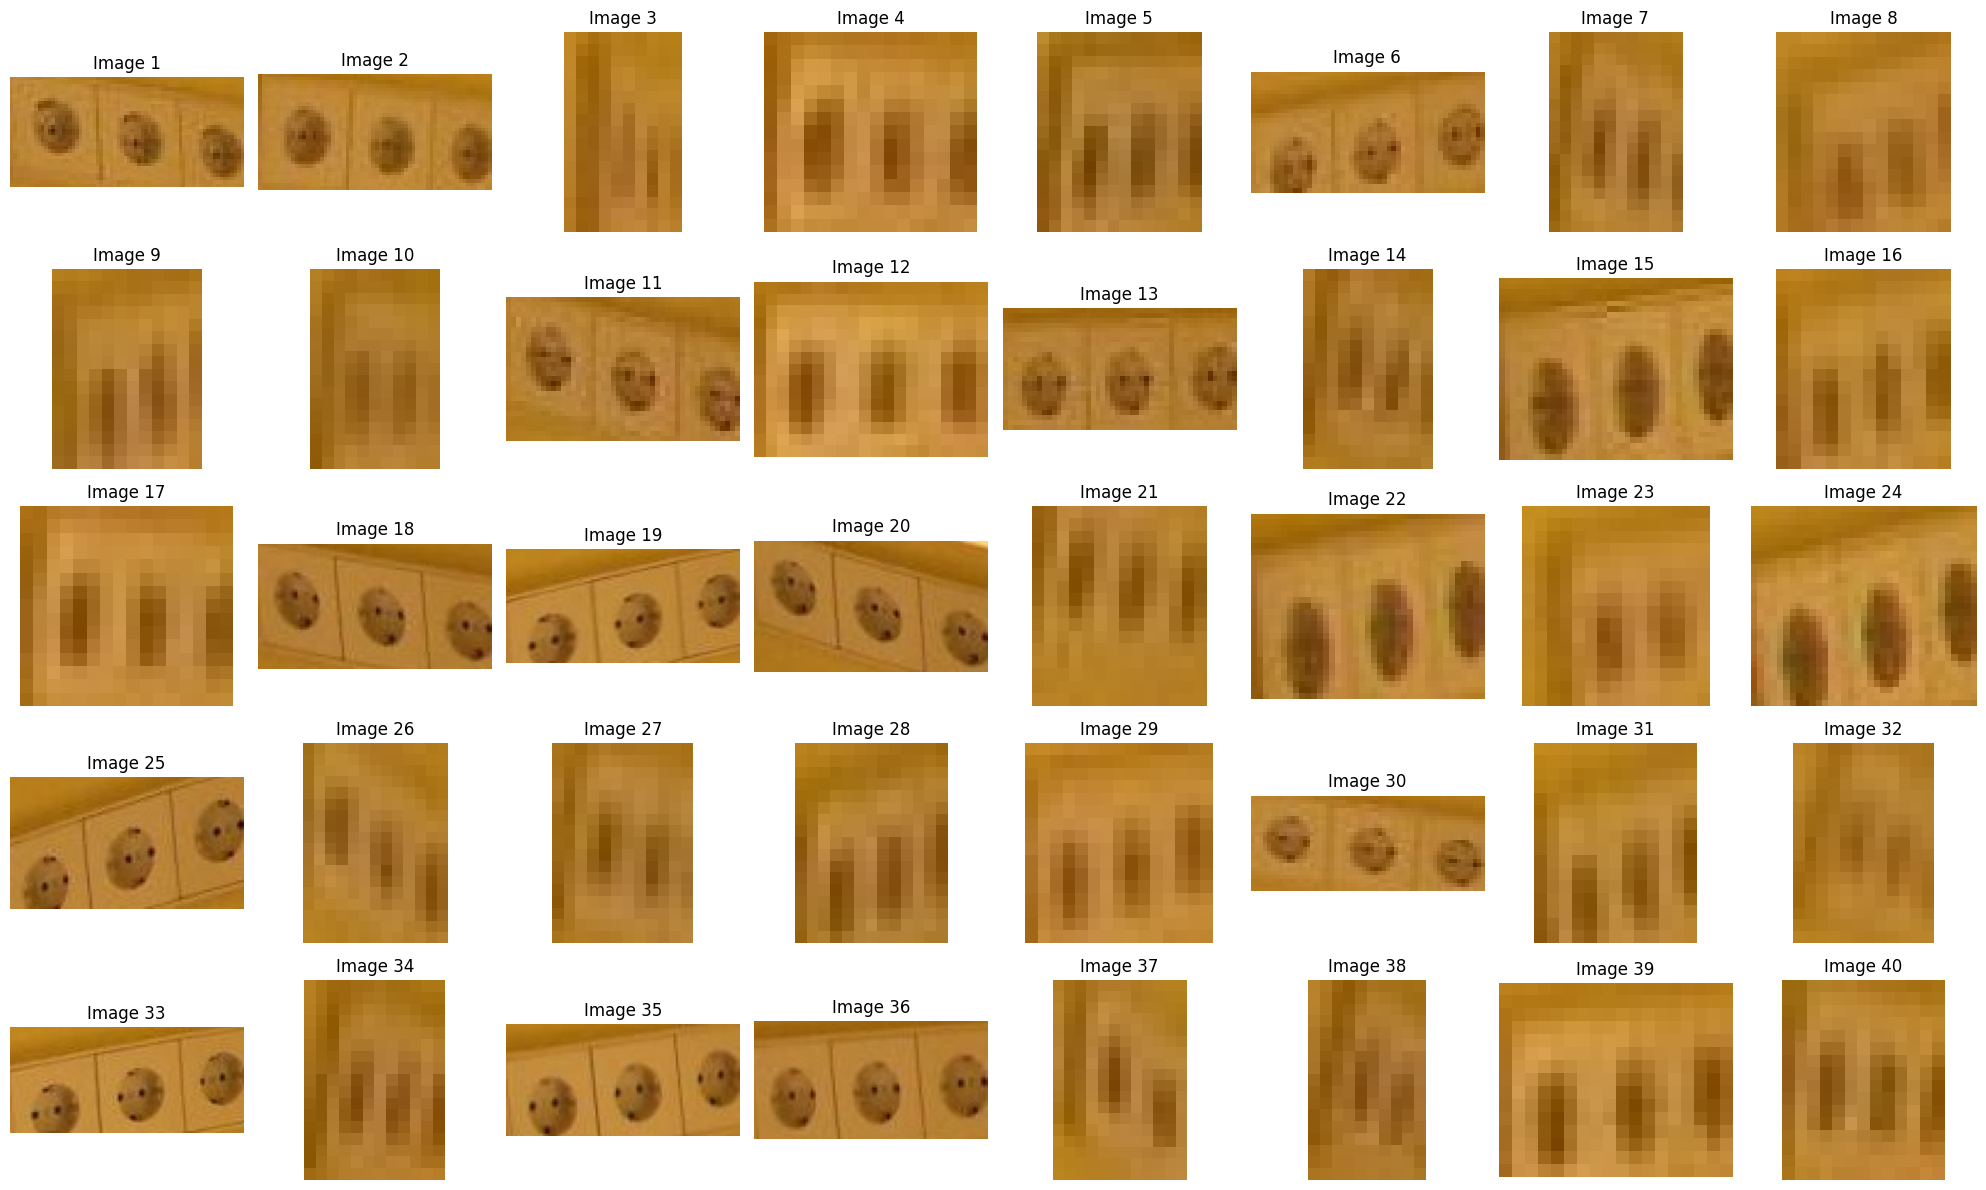

In [9]:
images_processing.cropped_image_visualization()

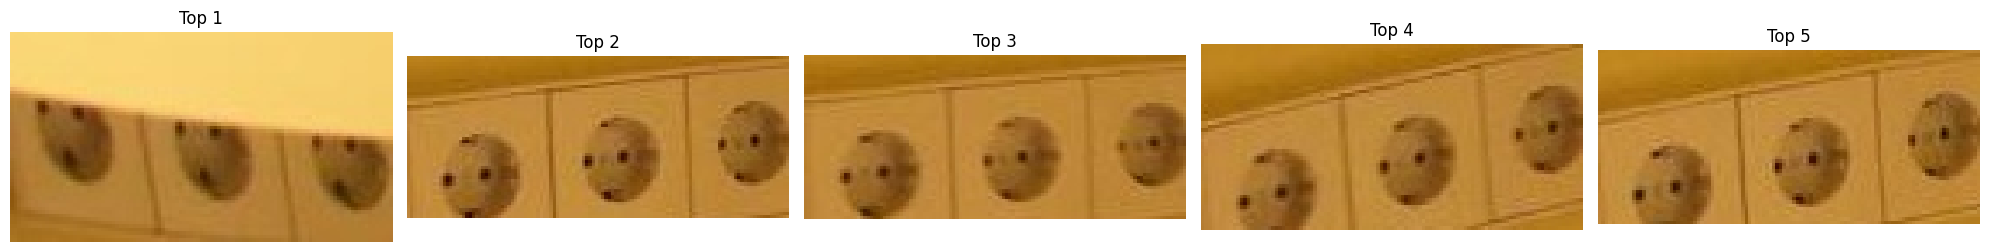

In [10]:
top5_images = images_processing.top5_view_selection(object_id=8)

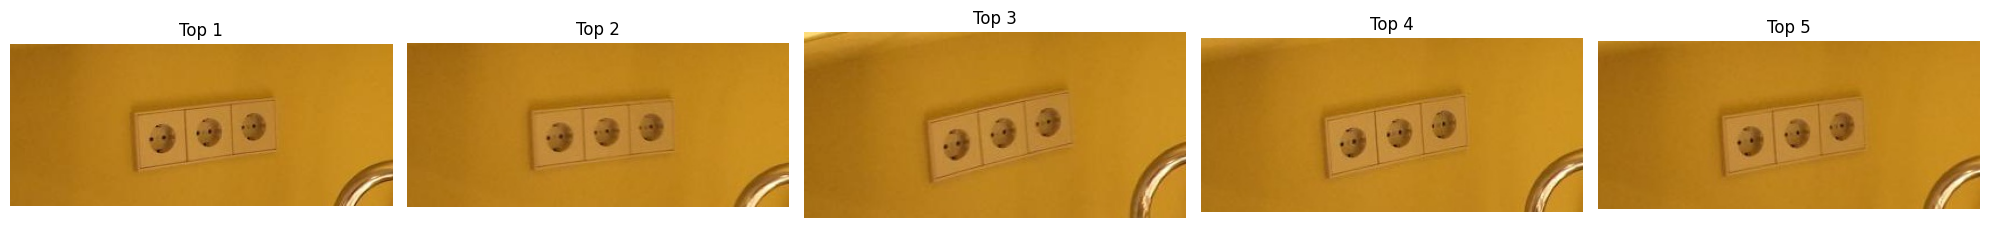

In [11]:
top5_images_with_surrounding = images_processing.top5_view_selection(image_path='ScanNet_Data/data/0a7cc12c0e/object_crops_padding', object_id=8)

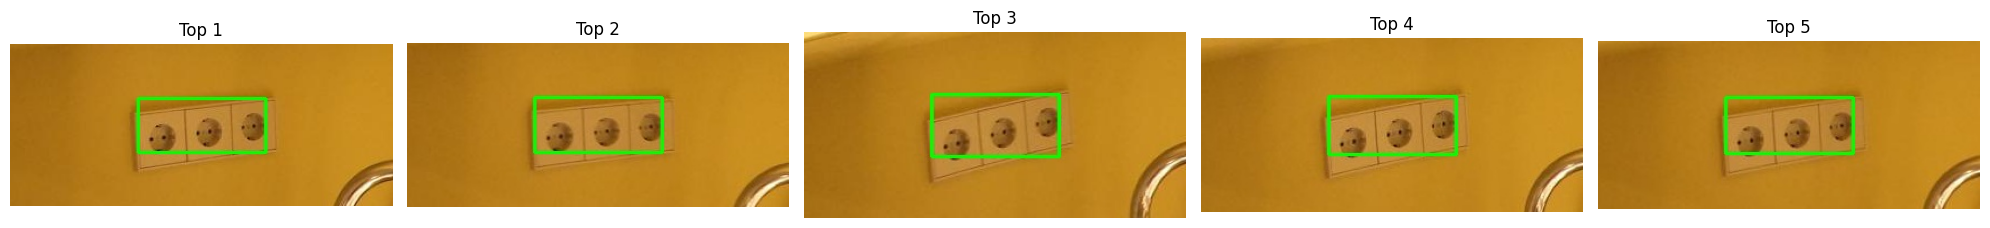

In [12]:
top5_images_with_surrounding = images_processing.top5_view_selection(image_path='ScanNet_Data/data/0a7cc12c0e/object_crops_padding_bbox', object_id=8)

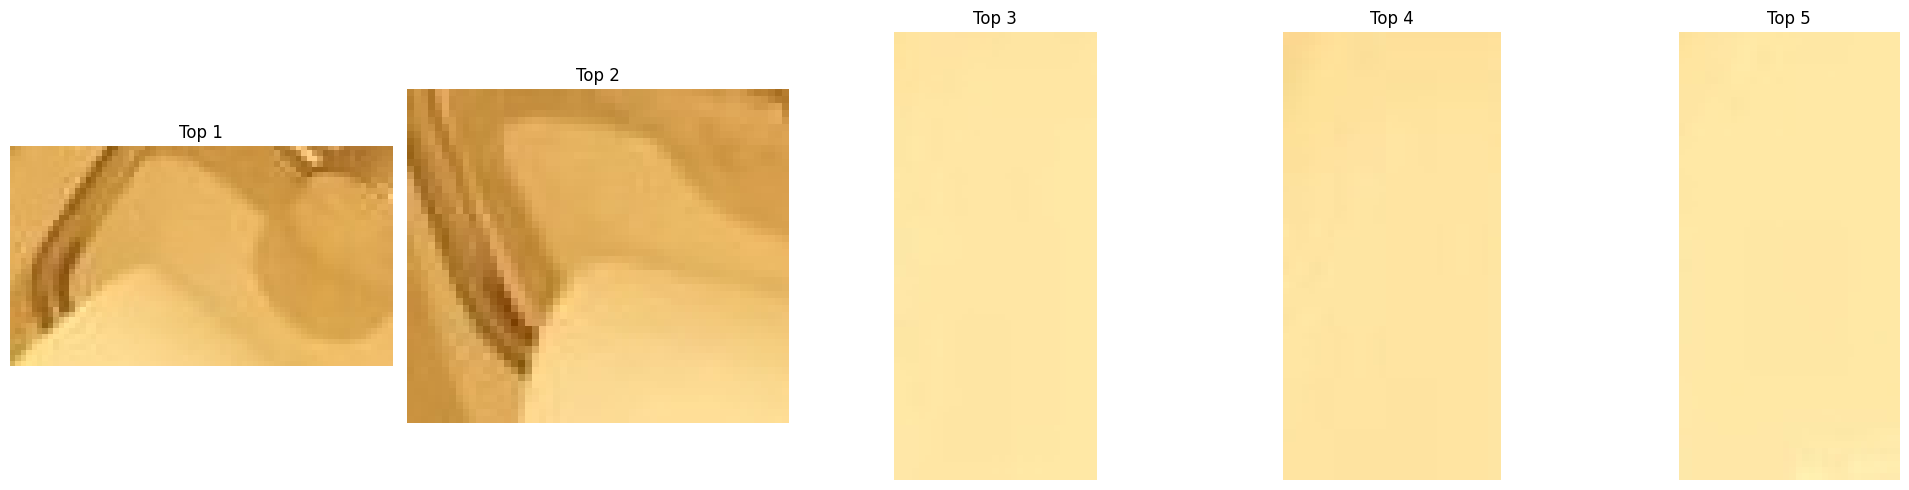

Output:
The image depicts a close-up view of a metallic object with a curved handle, possibly a part of a larger appliance or fixture. The object is primarily a light beige color with a smooth texture and a reflective surface. There are no visible buttons or unique patterns, and the object's shape is rectangular with rounded edges. The image is in a sepia tone, giving it a vintage or aged appearance.


In [ ]:
top5_images = images_processing.top5_view_selection(object_id=1)
cap_generator = caption_generator.Caption_Generator()
output = cap_generator.object_level_caption_refined(images=top5_images)

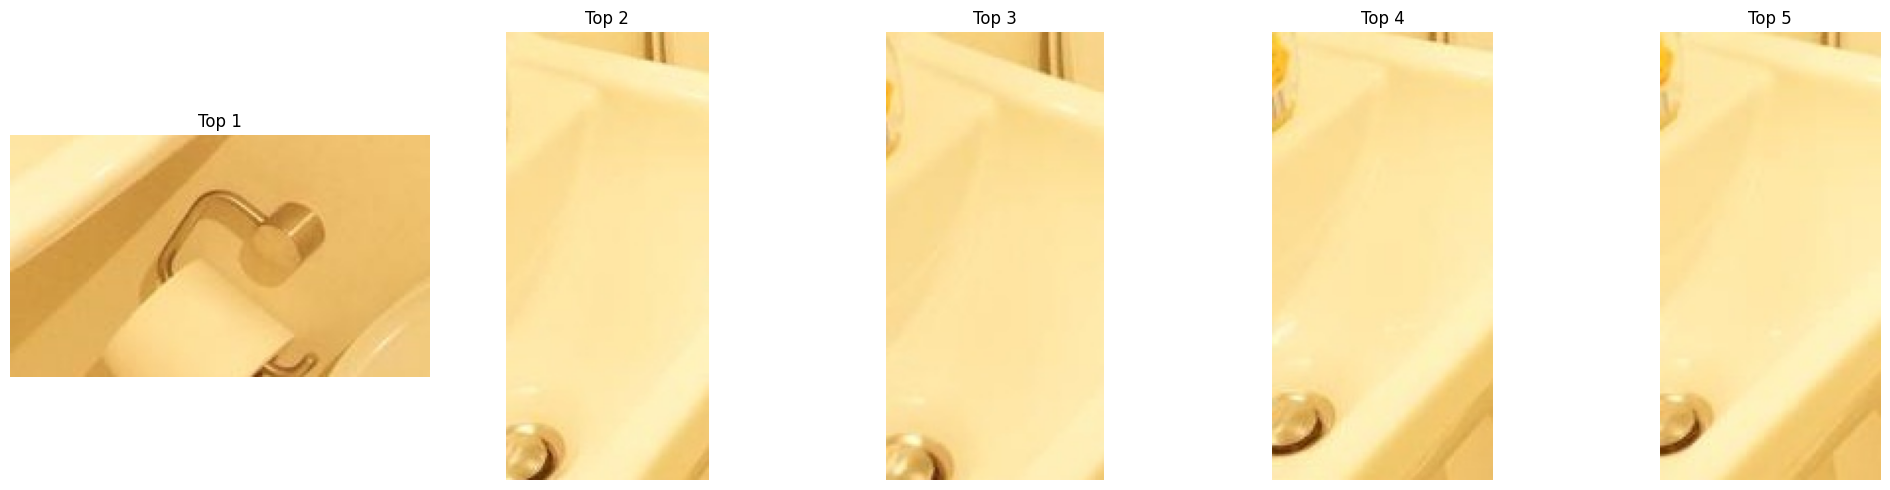

In [25]:
top5_images_with_surrounding = images_processing.top5_view_selection(image_path='ScanNet_Data/data/0a7cc12c0e/object_crops_padding', object_id=1)

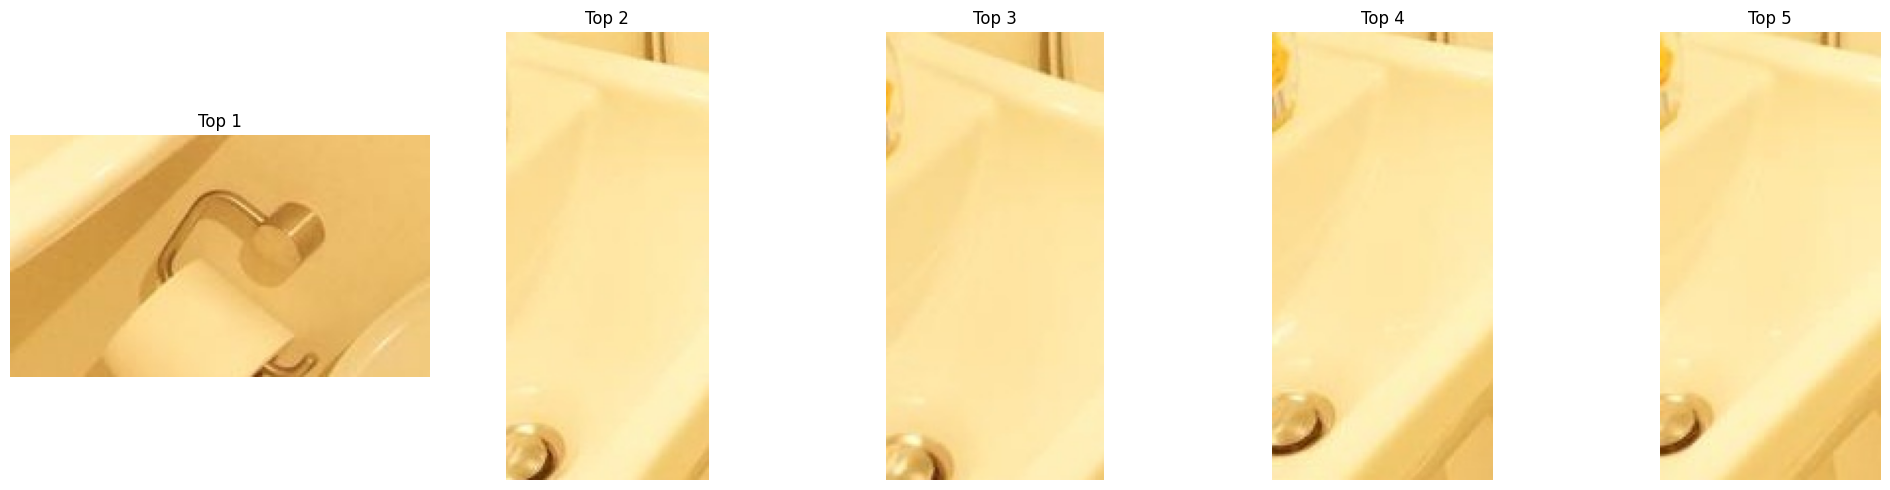

Output:
The image depicts a white porcelain bathroom sink with a silver drain, featuring a single roll of toilet paper mounted on a chrome holder. The sink's design is simple and functional, with a smooth, curved basin and a single hole for the drain. The color and texture are consistent with typical bathroom fixtures, and the chrome finish adds a touch of elegance.


In [29]:
top5_images_with_surrounding = images_processing.top5_view_selection(image_path='ScanNet_Data/data/0a7cc12c0e/object_crops_padding', object_id=1)
output = cap_generator.object_level_caption_refined(images=top5_images_with_surrounding)

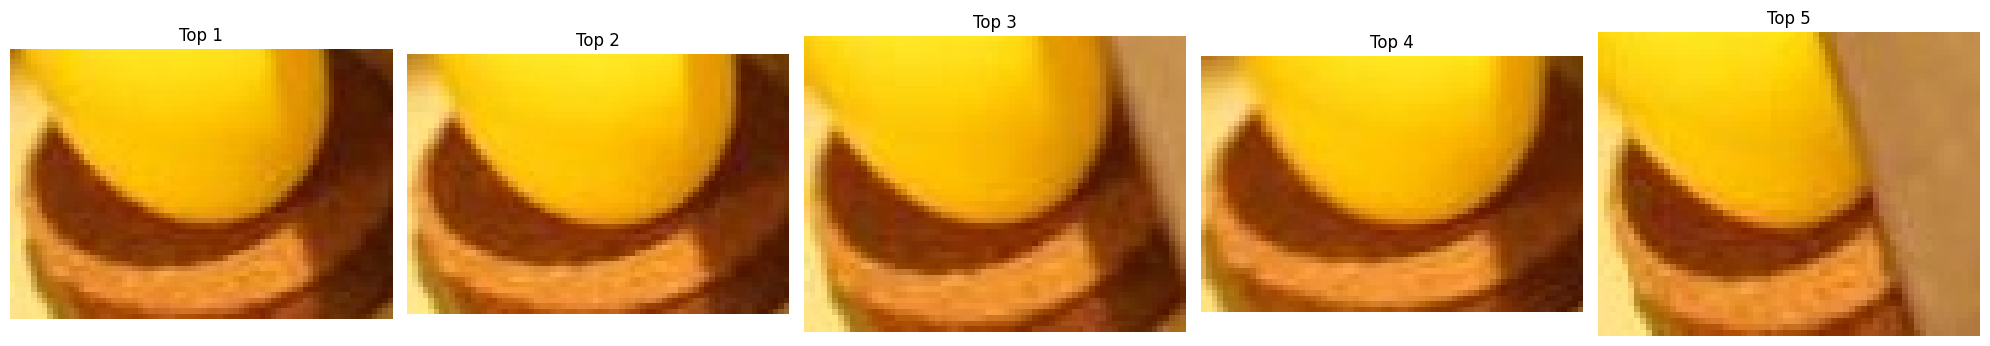

In [34]:
top5_images = images_processing.top5_view_selection(object_id=2)

# Object-Caption Generation

- For each object, select 5 multiview images and crop it to generate object-level caption.
- For each object, select 5 multiview images and with padding to preserve surrounding environment to generate surrounding caption.
- Use the distance between centroid and cos-similarity to build the edge between nodes.
- Build the scene-graph and use community detection to group objects.

In [13]:
import caption_generator
cap_generator = caption_generator.Caption_Generator()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


In [14]:
output = cap_generator.object_level_caption_refined(images=top5_images)

Output:
The image shows three identical round electrical outlets with a metallic appearance, mounted on a wall. The outlets have a standard European plug design, featuring two holes for the prongs and a central grounding pin. The color of the outlets is a metallic silver, and the wall they are mounted on is a light yellow, providing a warm contrast. The image is taken from a slightly angled perspective, focusing on the three outlets in a row.


### Surrounding Captions

In [15]:
cap_generator.single_image_surrounding_captioning(images_with_surrounding=top5_images_with_surrounding)

'This object is a white electrical outlet with three sockets, commonly used for plugging in electrical devices. It is positioned on a yellow wall, with a green rectangle highlighting it. The outlet is part of a larger electrical setup, and its placement suggests it is part of a standard home or office environment. The green rectangle serves to draw attention to the outlet, indicating its importance or relevance in the context of the image.'

## Capton for each object

### Detailed Object Level Caption from VLM

In [18]:
from tqdm import tqdm
captions = []
# len(unique_instances)
for i in tqdm(range(len(unique_instances)), desc='Generating Object Captions:'):
    obj = i+1

    top5_images = images_processing.top5_view_selection(object_id = obj, visualization=False)
    obj_level_caption = cap_generator.object_level_caption_refined(images = top5_images, max_partition=len(top5_images))

    top5_images_with_surrounding = images_processing.top5_view_selection(image_path='ScanNet_Data/data/0a7cc12c0e/object_crops_padding', object_id=obj, visualization=False)
    obj_surrounding_caption = cap_generator.single_image_surrounding_captioning(images_with_surrounding = top5_images_with_surrounding)

    obj_caption = {
        "object_id": obj,
        "object_caption": obj_level_caption,
        "surrounding_caption": obj_surrounding_caption
    }

    captions.append(obj_caption)

Generating Object Captions::   0%|          | 0/140 [00:00<?, ?it/s]

Output:
The image depicts a close-up view of a metallic object with a curved handle, possibly a part of a larger appliance or fixture. The object is primarily a light beige color with a smooth texture and a reflective surface. There are no visible buttons or unique patterns, and the object's shape is rectangular with rounded edges. The image is in a sepia tone, giving it a vintage or aged appearance.


Generating Object Captions::   1%|          | 1/140 [00:03<07:16,  3.14s/it]

Output:
The image depicts a close-up of a yellow spherical object with a smooth texture, resting on a brown circular base. The object has a glossy finish and features a series of small holes or buttons, suggesting it may be a button or a similar functional item. The overall color scheme is warm, with the yellow of the sphere contrasting against the brown of the base.


Generating Object Captions::   1%|▏         | 2/140 [00:05<06:30,  2.83s/it]

...

Generating Object Captions::  99%|█████████▊| 138/140 [08:40<00:06,  3.49s/it]

Output:
The image depicts a bedroom with a bed featuring a pink comforter with green leaf patterns, a laptop, and a red patterned lamp on a white nightstand. The wall is painted a light yellow, and the room is equipped with a microwave and a power outlet. The overall atmosphere is simple and functional, with minimal decoration.


Generating Object Captions::  99%|█████████▉| 139/140 [08:45<00:03,  3.97s/it]

Output:
The image depicts a stainless steel microwave oven with a digital display and control buttons, featuring a black-tinted glass door. The microwave is situated in a kitchen setting, with a reflection of a chair and a wall with a patterned tile design visible on the door. The digital display shows the time as 0:00, indicating that the microwave is not in use.


Generating Object Captions:: 100%|██████████| 140/140 [08:49<00:00,  3.78s/it]


In [35]:
captions[0]

{'object_id': 1,
 'object_caption': "The image depicts a close-up view of a metallic object with a curved handle, possibly a part of a larger appliance or fixture. The object is primarily a light beige color with a smooth texture and a reflective surface. There are no visible buttons or unique patterns, and the object's shape is rectangular with rounded edges. The image is in a sepia tone, giving it a vintage or aged appearance.",
 'surrounding_caption': 'This object is a white toilet paper holder mounted on a metallic arm, commonly found in bathrooms. It is positioned next to a white sink, which is part of a bathroom setup. The toilet paper is currently unrolled and resting on the holder. The sink is a standard white ceramic basin with a silver drain, and a portion of a yellow soap dispenser is visible at the edge of the sink. The surrounding area is brightly lit, suggesting a well-lit bathroom environment. The toilet paper holder is a functional item, providing a convenient place to 

In [36]:
captions[1]

{'object_id': 2,
 'object_caption': 'The image depicts a close-up of a yellow spherical object with a smooth texture, resting on a brown circular base. The object has a glossy finish and features a series of small holes or buttons, suggesting it may be a button or a similar functional item. The overall color scheme is warm, with the yellow of the sphere contrasting against the brown of the base.',
 'surrounding_caption': "This object is a yellow bottle with a green cap, resembling a lemon, placed on a round, brown coaster. It is positioned on a kitchen countertop, next to a wooden cutting board and a silver appliance, possibly a stove or oven. The bottle's shape and color suggest it may be used for cleaning or as a decorative kitchen item. The surrounding elements, such as the cutting board and the appliance, indicate a domestic kitchen setting."}

In [37]:
'''
with open("object_captions.json", "w", encoding="utf-8") as f:
    json.dump(captions, f, indent=2, ensure_ascii=False)
'''
with open("object_captions.json", "r", encoding="utf-8") as f:
    captions = json.load(f)

In [38]:
object_to_centroid = {}
for i, file in enumerate(os.listdir(output_dir)):
    mesh = o3d.io.read_triangle_mesh(os.path.join(output_dir, file))
    vertices = mesh.vertices
    triangles = mesh.triangles
    centroid = np.mean(vertices, axis=0)
    object_to_centroid[i+1] = centroid
with open("object_captions.json", "r", encoding="utf-8") as f:
    captions = json.load(f)

## Scene Graph

In [39]:
obj_1_cap = captions[0]
obj_1_centroid = object_to_centroid.get(1)

obj_2_cap = captions[1]
obj_2_centroid = object_to_centroid.get(2)

distance = np.linalg.norm(obj_1_centroid-obj_2_centroid)

In [40]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Combine object + surrounding caption
texts = [
    obj_1_cap['surrounding_caption'],
    obj_2_cap['surrounding_caption']    
]
embeddings = model.encode(texts, normalize_embeddings=True)

In [41]:
sim = np.dot(embeddings[0], embeddings[1])
print(f'The similarity between these objects is: {sim}')
print(f'The distance between these objects is: {distance}')

The similarity between these objects is: 0.5211747288703918
The distance between these objects is: 1.68140729413912


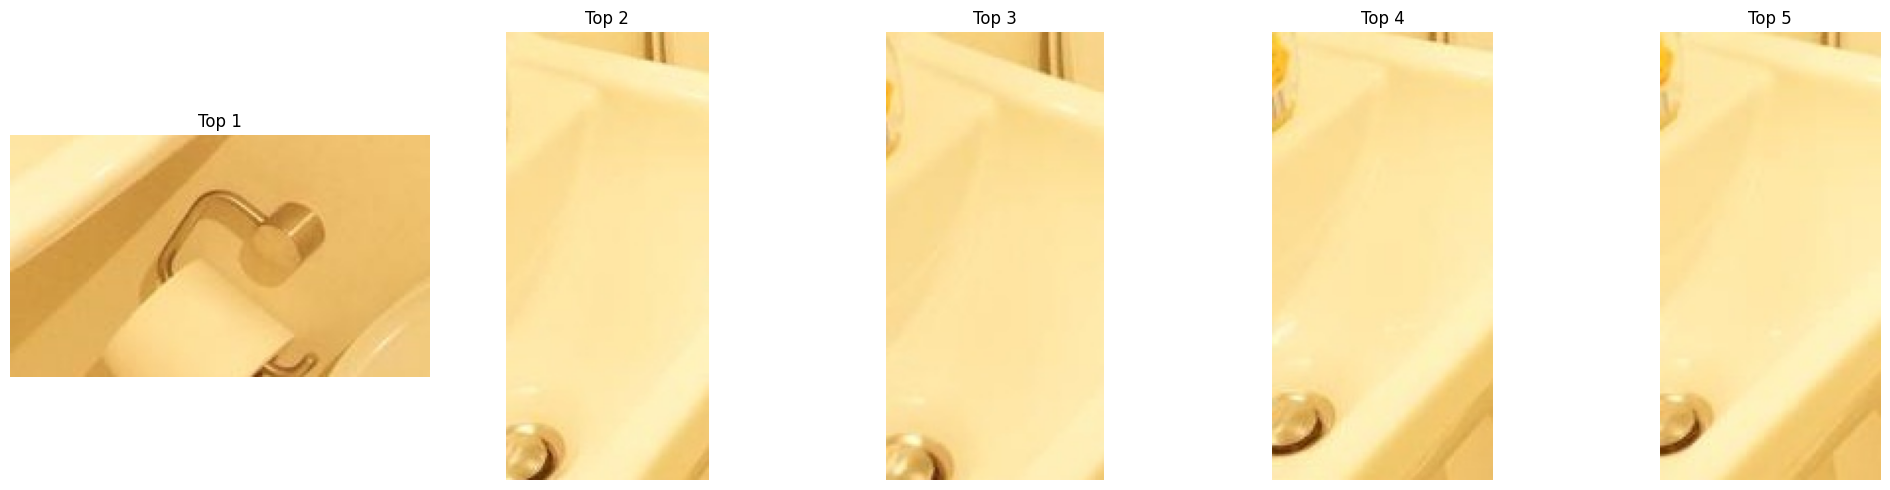

In [42]:
top5_images_with_surrounding = images_processing.top5_view_selection(image_path='ScanNet_Data/data/0a7cc12c0e/object_crops_padding', object_id=1)

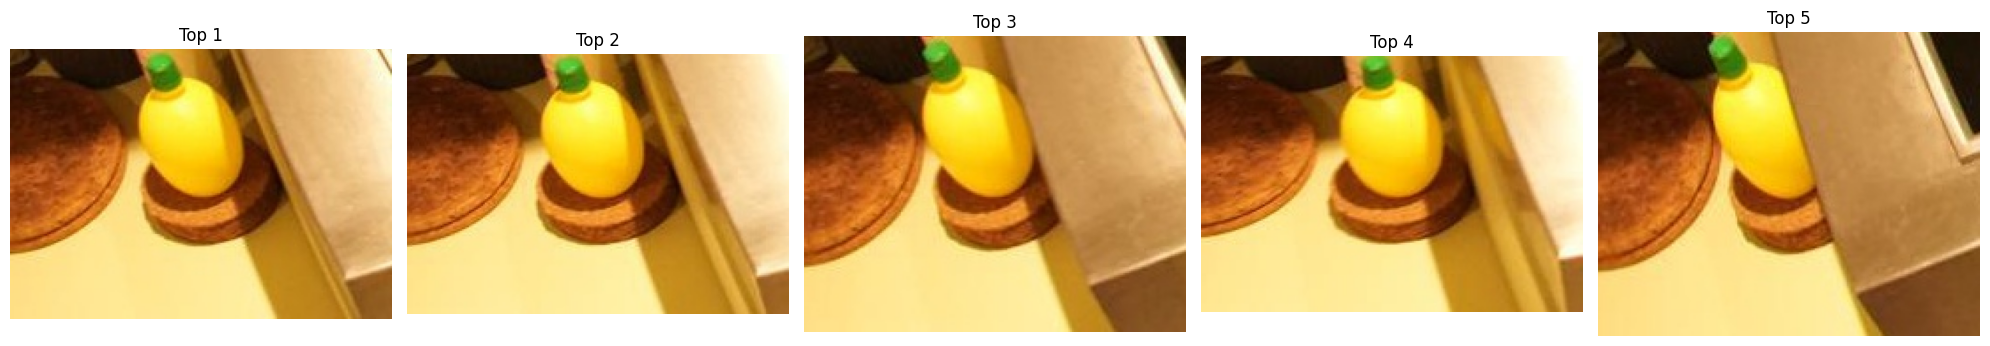

In [43]:
top5_images_with_surrounding = images_processing.top5_view_selection(image_path='ScanNet_Data/data/0a7cc12c0e/object_crops_padding', object_id=2)

In [44]:
# pip install numpy networkx sentence-transformers scikit-learn
# !pip3 install python-louvain

In [45]:
texts = [obj['surrounding_caption'] for obj in captions]
embeddings = model.encode(texts, normalize_embeddings=True)

In [46]:
for obj, emb in zip(captions, embeddings):
    obj['embeddings'] = emb

In [47]:
for obj, centroid in zip(captions, object_to_centroid.values()):
    obj['centroid'] = centroid

In [48]:
captions_with_embeddings = captions
captions_with_embeddings = sorted(captions_with_embeddings, key=lambda x: x['object_id'])

# Convert numpy arrays to lists for JSON serialization
for obj in captions_with_embeddings:
    if isinstance(obj.get('embeddings'), np.ndarray):
        obj['embeddings'] = obj['embeddings'].tolist()
    if isinstance(obj.get('centroid'), np.ndarray):
        obj['centroid'] = obj['centroid'].tolist()

with open("object_captions_with_embeddings.json", "w", encoding="utf-8") as f:
    json.dump(captions_with_embeddings, f, indent=2, ensure_ascii=False)

In [49]:
from itertools import combinations
import networkx as nx

G = nx.Graph()

# Add nodes
for obj in captions_with_embeddings:
    G.add_node(obj["object_id"], **obj)

# Build edges: weight = α * (1 / distance) + β * similarity
alpha, beta = 0.5, 0.5

for o1, o2 in combinations(captions_with_embeddings, 2):
    id1, id2 = o1["object_id"], o2["object_id"]

    # Distance
    dist = np.linalg.norm(np.array(o1["centroid"]) - np.array(o2["centroid"]))
    inv_dist = 1 / (dist + 1e-8)

    # Cosine similarity
    sim = np.dot(o1["embeddings"], o2["embeddings"])

    # Combined weight
    weight = alpha * inv_dist + beta * sim

    G.add_edge(id1, id2, weight=weight, distance=dist, similarity=sim)

In [50]:
import community as community_louvain

partition = community_louvain.best_partition(G, weight='weight')
for node_id, region_id in partition.items():
    G.nodes[node_id]['region'] = f'region_{region_id}'

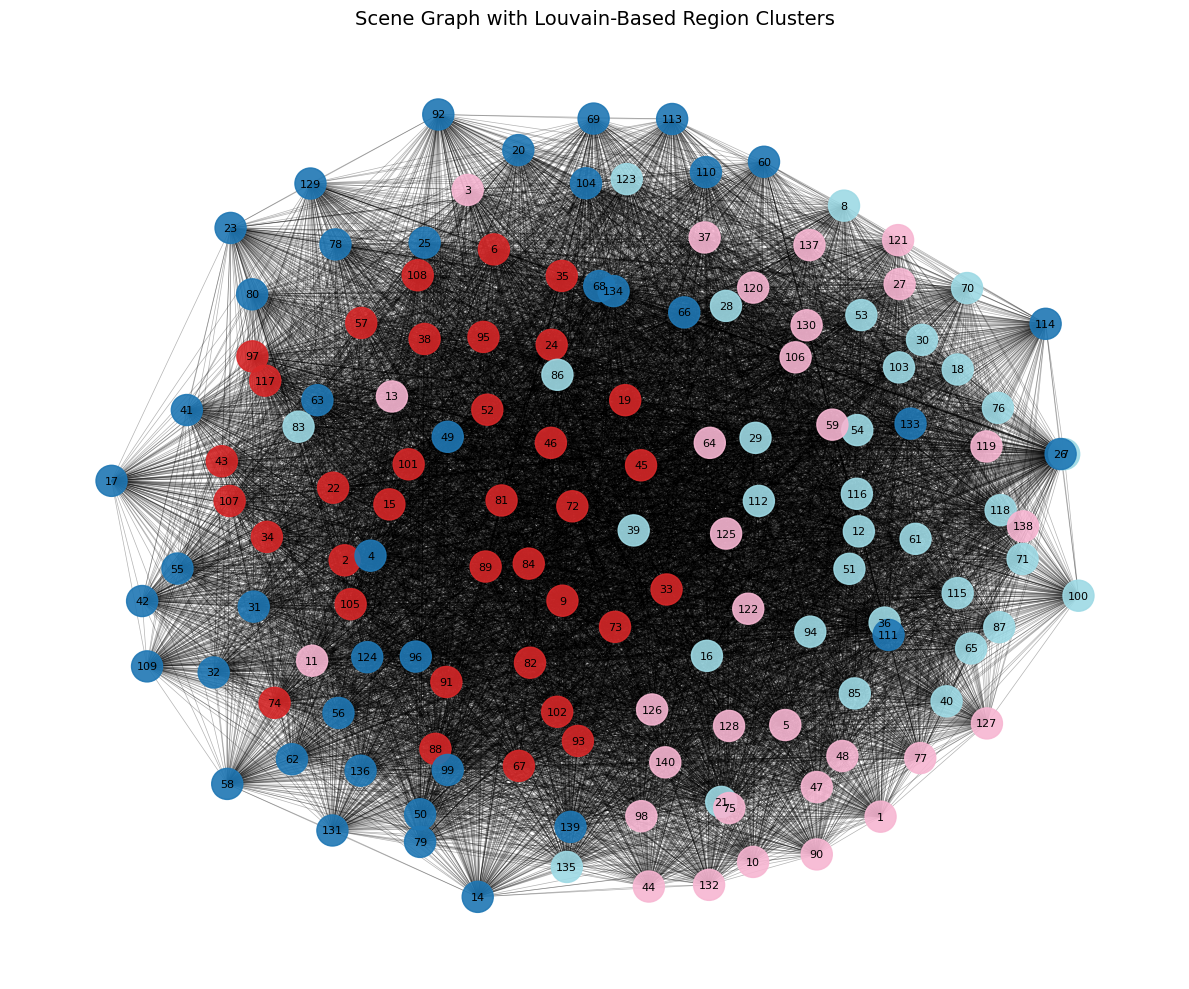

In [51]:
import matplotlib.pyplot as plt
import networkx as nx

# Use spring layout (force-directed)
pos = nx.spring_layout(G, weight="weight", seed=42)

# Extract all regions and assign a color map
regions = list(set(nx.get_node_attributes(G, "region").values()))
region_to_color = {r: i for i, r in enumerate(regions)}
colors = [region_to_color[G.nodes[n]["region"]] for n in G.nodes]

# Plot
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(
    G, pos,
    node_color=colors,
    cmap=plt.cm.tab20,
    node_size=500,
    alpha=0.9
)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Scene Graph with Louvain-Based Region Clusters", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [52]:
print(f"Detected {len(regions)} regions via Louvain.")

Detected 4 regions via Louvain.


In [53]:
from collections import defaultdict
region_groups = defaultdict(list)
for n in G.nodes:
    region = G.nodes[n]["region"]
    caption = G.nodes[n]["object_caption"]
    region_groups[region].append(caption)

# 打印区域内容
for region, items in region_groups.items():
    print(f"{region}: {len(items)} objects")

region_0: 31 objects
region_2: 35 objects
region_3: 41 objects
region_1: 33 objects


In [54]:
from collections import defaultdict
# collect object IDs by region
region_groups = defaultdict(list)
for node in G.nodes:
    region = G.nodes[node]['region']
    region_groups[region].append(node)

# print region groups with object IDs
for region, obj_ids in sorted(region_groups.items()):
    print(f"{region} ({len(obj_ids)} objects):")
    print(", ".join(map(str, obj_ids)))
    print()

region_0 (31 objects):
1, 3, 5, 10, 11, 13, 27, 37, 44, 47, 48, 59, 64, 75, 77, 90, 98, 106, 119, 120, 121, 122, 125, 126, 127, 128, 130, 132, 137, 138, 140

region_1 (33 objects):
7, 8, 12, 16, 18, 21, 28, 29, 30, 36, 39, 40, 51, 53, 54, 61, 65, 70, 71, 76, 83, 85, 86, 87, 94, 100, 103, 112, 115, 116, 118, 123, 135

region_2 (35 objects):
2, 6, 9, 15, 19, 22, 24, 33, 34, 35, 38, 43, 45, 46, 52, 57, 67, 72, 73, 74, 81, 82, 84, 88, 89, 91, 93, 95, 97, 101, 102, 105, 107, 108, 117

region_3 (41 objects):
4, 14, 17, 20, 23, 25, 26, 31, 32, 41, 42, 49, 50, 55, 56, 58, 60, 62, 63, 66, 68, 69, 78, 79, 80, 92, 96, 99, 104, 109, 110, 111, 113, 114, 124, 129, 131, 133, 134, 136, 139



In [55]:
# Add region info to captions
for obj in captions_with_embeddings:
    obj_id = int(obj["object_id"])
    if obj_id in G.nodes and "region" in G.nodes[obj_id]:
        obj["region"] = G.nodes[obj_id]["region"]
    else:
        obj["region"] = "unknown"

In [56]:
print(captions_with_embeddings[0])
print(captions_with_embeddings[0]['region'])

{'object_id': 1, 'object_caption': "The image depicts a close-up view of a metallic object with a curved handle, possibly a part of a larger appliance or fixture. The object is primarily a light beige color with a smooth texture and a reflective surface. There are no visible buttons or unique patterns, and the object's shape is rectangular with rounded edges. The image is in a sepia tone, giving it a vintage or aged appearance.", 'surrounding_caption': 'This object is a white toilet paper holder mounted on a metallic arm, commonly found in bathrooms. It is positioned next to a white sink, which is part of a bathroom setup. The toilet paper is currently unrolled and resting on the holder. The sink is a standard white ceramic basin with a silver drain, and a portion of a yellow soap dispenser is visible at the edge of the sink. The surrounding area is brightly lit, suggesting a well-lit bathroom environment. The toilet paper holder is a functional item, providing a convenient place to st

In [59]:
import plotly.express as px
import numpy as np
import json

data = []
for obj in captions:
    obj_id = int(obj["object_id"])
    centroid = object_to_centroid.get(obj_id)
    if centroid is not None:
        data.append({
            "id": obj_id,
            "x": centroid[0],
            "y": centroid[1],
            "z": centroid[2],
            "caption": obj["object_caption"],
            "region": obj['region'] # fallback if region not added yet
        })

# Sort by region for consistent coloring
import pandas as pd
df = pd.DataFrame(data)
df["region"] = df["region"].astype(str)

# 3D scatter plot
fig = px.scatter_3d(
    df,
    x='x', y='y', z='z',
    color='region',
    hover_data=['id', 'region'],
    title="3D Visualization of Object Centroids Colored by Region",
    opacity=0.8
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

## Map the Region to the Submesh

In [61]:
# Map the Region to the Submesh
print(len(region_groups['region_0']))
extracted_objects_dir = 'ScanNet_Data/data/0a7cc12c0e/extracted_individual_objects'
region_0_objects = region_groups['region_0']
region_0_submesh = o3d.geometry.TriangleMesh()
for obj_id in region_0_objects:
    for file in os.listdir(extracted_objects_dir):
        object_id = str(obj_id)
        if f'object_{object_id}_' in file and file.endswith('.ply'):
            obj_mesh = o3d.io.read_triangle_mesh(os.path.join(extracted_objects_dir, file))
            region_0_submesh += obj_mesh

31


In [42]:
whole_desc = f'This is a description of the current region, which contains {len(region_0_objects)} objects.\n\n'
for i in region_0_objects:
    desc = f'This is a description of object {i} in our current region:'
    object_cap = captions_with_embeddings[i-1].get('object_caption', 'No caption available')
    surrounding_cap = captions_with_embeddings[i-1].get('surrounding_caption', 'No caption available')
    desc += f'\nObject Level Description:\n{object_cap}\nSurroundings Description:\n{surrounding_cap}\n\n'
    whole_desc += desc

In [72]:
for n in G.nodes:
    region = G.nodes[n]["region"]
    G.nodes[n]['region_category'] = int(region.replace('region_', ''))

In [75]:
with open("object_captions_with_embeddings.json", "r", encoding="utf-8") as f:
    captions_with_embeddings = json.load(f)    

In [77]:
captions_with_embeddings[0].keys()

dict_keys(['object_id', 'object_caption', 'surrounding_caption', 'embeddings', 'centroid'])

In [79]:
for n in G.nodes:
    captions_with_embeddings[n-1]['region'] = G.nodes[n]['region_category']

In [ ]:
with open('object_captions_with_embeddings.json', 'w', encoding='utf-8') as f:
    json.dump(captions_with_embeddings, f, indent=2, ensure_ascii=False)

: 